### **Assignment 3** — Detect and Fix Multicollinearity
Objective Understand multicollinearity problems in Linear Regression.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files  #Comment out if you ar runnin locally
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [ ]:
uploaded = files.upload()  #Comment out if you ar runnin locally


Saving Advertising.csv to Advertising.csv


In [3]:
df = pd.read_csv('Advertising.csv')
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


,0
Unnamed: 0,0
TV,0
radio,0
newspaper,0
sales,0


Corr matrix

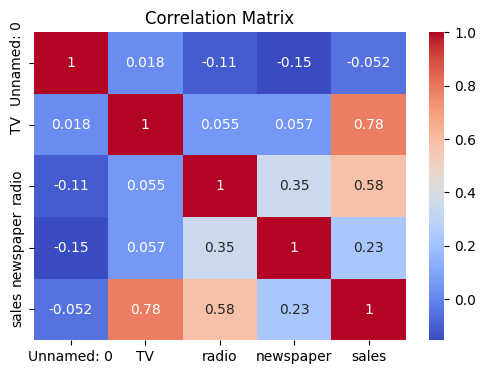

In [5]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [9]:
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

Train, Evaluate Model

In [10]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [12]:
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Baseline Model")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Baseline Model
MAE: 1.4607567168117603
RMSE: 1.78159966153345
R2: 0.899438024100912


Calculate VIF

In [13]:
X_vif = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

     Feature       VIF
0      const  6.848900
1         TV  1.004611
2      radio  1.144952
3  newspaper  1.145187


No feature will be removed as no feature's VIF exceeds 2, none are removed, model remains the same.

To just compare, lets remove any one feature

In [15]:
X_new = df[['TV', 'radio']]   # removed Newspaper

Train, Evaluate New Model

In [16]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

pred2 = model2.predict(X_test2)

In [17]:
mae2 = mean_absolute_error(y_test2, pred2)
rmse2 = np.sqrt(mean_squared_error(y_test2, pred2))
r2_2 = r2_score(y_test2, pred2)

print("\nAfter Removing Multicollinearity")
print("MAE:", mae2)
print("RMSE:", rmse2)
print("R2:", r2_2)


After Removing Multicollinearity
MAE: 1.4443023138227578
RMSE: 1.7714254173033517
R2: 0.9005833101920356


Compare Models

In [18]:
comparison = pd.DataFrame({
    'Model': ['Before Removal', 'After Removal'],
    'MAE': [mae, mae2],
    'RMSE': [rmse, rmse2],
    'R2': [r2, r2_2]
})

comparison

,Model,MAE,RMSE,R2
0,Before Removal,1.460757,1.781600,0.899438
1,After Removal,1.444302,1.771425,0.900583


In [19]:
print("Before Removal:", model.coef_)
print("After Removal:", model2.coef_)

Before Removal: [0.04472952 0.18919505 0.00276111]
After Removal: [0.0447283  0.19066726]
